# Прогнозирование стоимости жилья в Калифорнии
## Линейная регрессия

---

**Задача:** научить программу предсказывать медианную стоимость дома в районе
по его характеристикам и географическому расположению.

**Тип задачи:** регрессия — мы предсказываем число (цену), а не класс объекта.

**Алгоритм:** линейная регрессия (Linear Regression).

**Инструменты:** Python, pandas, scikit-learn, matplotlib, seaborn, MLflow.

В этом ноутбуке каждое действие подробно объясняется в комментариях,
чтобы разобраться мог даже человек, который программирует впервые.

## 1. Зависимости

Для работы нужны следующие библиотеки:

    pandas          — работа с таблицами
    numpy           — математика и массивы чисел
    scikit-learn    — машинное обучение (модели, метрики, датасеты)
    matplotlib      — построение графиков
    seaborn         — красивые статистические графики
    mlflow          — запись и сравнение экспериментов

Если вы запускаете ноутбук в Google Colab, зависимости можно поставить так:

    !pip install -q pandas numpy scikit-learn matplotlib seaborn mlflow

В локальной среде они уже установлены.

In [1]:
# ============================================================
# ЯЧЕЙКА ЗАВИСИМОСТЕЙ
# Здесь мы подключаем все библиотеки, которые понадобятся дальше.
# ============================================================

# pandas — библиотека для работы с таблицами (как Excel, только в коде).
# Сокращаем её имя до pd, чтобы каждый раз не писать полностью.
import pandas as pd

# numpy — библиотека для математических операций и работы с массивами чисел.
# Сокращаем имя до np.
import numpy as np

# matplotlib.pyplot — модуль для рисования графиков.
# Сокращаем имя до plt.
import matplotlib.pyplot as plt

# seaborn — надстройка над matplotlib, которая рисует статистические графики
# красивее и требует меньше кода. Сокращаем имя до sns.
import seaborn as sns

# fetch_california_housing — функция, которая скачивает нужный нам датасет
# прямо из библиотеки scikit-learn, вручную искать файл не надо.
from sklearn.datasets import fetch_california_housing

# train_test_split — функция, которая делит данные на две части:
# одну для обучения модели, другую для проверки.
from sklearn.model_selection import train_test_split

# LinearRegression — сама модель линейной регрессии.
from sklearn.linear_model import LinearRegression

# mean_squared_error — метрика, показывающая среднюю величину ошибки.
# r2_score — метрика, показывающая, какую долю закономерностей уловила модель.
from sklearn.metrics import mean_squared_error, r2_score

# mlflow — инструмент для ведения журнала экспериментов.
# Он сохраняет параметры модели и метрики, чтобы можно было их сравнивать.
import mlflow

# mlflow.sklearn — дополнительный модуль MLflow, умеющий сохранять
# модели, написанные на scikit-learn.
import mlflow.sklearn

# sklearn нужен целиком только для того, чтобы вывести его версию.
import sklearn

# ------------------------------------------------------------
# Настройки внешнего вида графиков
# ------------------------------------------------------------

# Включаем аккуратную тему оформления с белым фоном и сеткой.
sns.set_theme(style="whitegrid")

# Задаём размер графиков по умолчанию: 10 на 6 условных единиц.
plt.rcParams["figure.figsize"] = (10, 6)

# Задаём базовый размер шрифта на графиках.
plt.rcParams["font.size"] = 11

# Разрешаем выводить таблицы целиком, не обрезая столбцы многоточием.
pd.set_option("display.max_columns", None)

# ------------------------------------------------------------
# Проверяем, что всё подключилось, и печатаем версии библиотек.
# Версии важно фиксировать: от них зависит воспроизводимость результата.
# ------------------------------------------------------------
print("pandas       :", pd.__version__)
print("numpy        :", np.__version__)
print("scikit-learn :", sklearn.__version__)
print("matplotlib   :", plt.matplotlib.__version__)
print("seaborn      :", sns.__version__)
print("mlflow       :", mlflow.__version__)
print()
print("Все библиотеки подключены успешно.")

pandas       : 3.0.5
numpy        : 2.5.3
scikit-learn : 1.9.1
matplotlib   : 3.11.2
seaborn      : 0.13.2
mlflow       : 3.16.1

Все библиотеки подключены успешно.


## 2. Описание датасета

**Источник:** встроенный набор данных библиотеки scikit-learn
(изначально собран из переписи населения США 1990 года).

**Размер:** 20 640 строк (районов Калифорнии) и 8 числовых признаков.

| Признак | Что означает |
|---|---|
| MedInc | медианный доход жителей района |
| HouseAge | медианный возраст дома в районе |
| AveRooms | среднее число комнат на домохозяйство |
| AveBedrms | среднее число спален на домохозяйство |
| Population | население района |
| AveOccup | среднее число жителей на домохозяйство |
| Latitude | географическая широта района |
| Longitude | географическая долгота района |

**Целевая переменная:** MedHouseVal — медианная стоимость дома,
измеряется в сотнях тысяч долларов. Значение 4.526 означает 452 600 долларов.

**Пропусков в датасете нет** — он подготовлен авторами scikit-learn.
Но проверить это мы обязаны самостоятельно, и ниже сделаем это честно.

In [2]:
# Скачиваем датасет California Housing из библиотеки scikit-learn.
# При первом запуске данные скачаются из интернета, дальше берутся из кэша.
housing = fetch_california_housing()

# housing.data — это массив чисел с признаками (характеристиками районов).
# pd.DataFrame превращает его в удобную таблицу,
# а параметр columns задаёт названия столбцов.
X = pd.DataFrame(housing.data, columns=housing.feature_names)

# housing.target — это целевая переменная, то есть то, что мы предсказываем.
# pd.Series превращает её в отдельный столбец с понятным именем MedHouseVal.
y = pd.Series(housing.target, name="MedHouseVal")

# Копируем таблицу признаков, чтобы случайно не испортить исходные данные.
df = X.copy()

# Добавляем к признакам столбец с ценой — так удобнее проводить анализ.
df["MedHouseVal"] = y

# Печатаем размеры: shape возвращает пару (число строк, число столбцов).
print("Таблица признаков X :", X.shape)
print("Целевая переменная y:", y.shape)
print("Общая таблица df    :", df.shape)

Таблица признаков X : (20640, 8)
Целевая переменная y: (20640,)
Общая таблица df    : (20640, 9)


## 3. Разведочный анализ данных (EDA)

EDA — это первичное знакомство с данными до построения модели.
Мы отвечаем на вопросы: что внутри, всё ли на месте, нет ли мусора.

Проверим по порядку:

1. общий вид таблицы;
2. пропуски;
3. дубликаты;
4. аномалии и выбросы;
5. распределения значений;
6. корреляции между признаками.

### 3.1 Первый взгляд на данные

In [3]:
# .shape показывает размер таблицы в формате (строки, столбцы).
print("Размер таблицы:", df.shape)

# .head() выводит первые 5 строк — чтобы глазами оценить, как выглядят данные.
df.head()

Размер таблицы: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# .info() показывает по каждому столбцу:
# имя, количество непустых значений и тип данных.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
# .describe() считает основную статистику по каждому числовому столбцу:
# количество, среднее, стандартное отклонение, минимум, квартили и максимум.
# .T переворачивает таблицу, чтобы столбцы стали строками и всё поместилось.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


### 3.2 Проверка пропусков

Пропуск — это пустая ячейка. Если такие есть, модель обучится неправильно
или вообще откажется работать, поэтому проверяем в первую очередь.

In [6]:
# .isnull() превращает таблицу в такую же по размеру таблицу из True и False:
# True там, где значение пустое.
# .sum() складывает True как единицы и False как нули,
# то есть считает количество пропусков в каждом столбце.
missing = df.isnull().sum()

# Выводим результат по столбцам.
print("Пропуски по столбцам:")
print(missing)

# Складываем все значения, чтобы получить общее число пропусков.
print()
print("Всего пропусков в датасете:", missing.sum())
print("Доля пропусков, %:", round(missing.sum() / df.size * 100, 4))

Пропуски по столбцам:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Всего пропусков в датасете: 0
Доля пропусков, %: 0.0


**Вывод:** пропусков нет ни в одном столбце, дополнительная обработка не нужна.

### 3.3 Проверка дубликатов

Дубликат — это строка, полностью повторяющая другую.
Они искажают статистику: модель начинает считать повторяющийся случай
закономерностью.

In [7]:
# .duplicated() помечает как True каждую строку,
# которая полностью совпадает с какой-то из предыдущих строк.
# .sum() считает количество таких строк.
n_duplicates = df.duplicated().sum()

# Печатаем количество дубликатов.
print("Количество полных дубликатов:", n_duplicates)

# Печатаем долю дубликатов от общего числа строк.
print("Доля дубликатов, %:", round(n_duplicates / len(df) * 100, 4))

# Для честности проверим дубликаты и по одним лишь признакам,
# без учёта цены: бывает, что одинаковые дома просто имеют разную цену.
n_dup_features = df[X.columns].duplicated().sum()
print("Дубликатов только по признакам:", n_dup_features)

Количество полных дубликатов: 0
Доля дубликатов, %: 0.0
Дубликатов только по признакам: 0


**Вывод:** полных дубликатов нет. Это ожидаемо: значения признаков
дробные и с высокой точностью, поэтому повториться строка может крайне редко.

### 3.4 Поиск аномалий и выбросов

**Выброс** — это значение, которое сильно выбивается из общего ряда.
Например, если среднее число комнат в районе равно 50, тогда как
у всех остальных — от 4 до 8, это подозрительно.

Самый распространённый способ поиска — **правило межквартильного размаха (IQR)**:

1. находим первый квартиль Q1 (25 % данных ниже него);
2. находим третий квартиль Q3 (75 % данных ниже него);
3. считаем IQR = Q3 − Q1 — ширину «центральной» части данных;
4. всё, что ниже Q1 − 1.5 × IQR или выше Q3 + 1.5 × IQR, объявляем выбросом.

In [8]:
# Объявляем функцию, которая считает количество выбросов в одном столбце.
# Функция — это как маленький станок: подаём данные, получаем результат.
def count_outliers(series):
    """Считает выбросы по правилу межквартильного размаха (IQR)."""

    # .quantile(0.25) возвращает первый квартиль — 25-й процентиль.
    q1 = series.quantile(0.25)

    # .quantile(0.75) возвращает третий квартиль — 75-й процентиль.
    q3 = series.quantile(0.75)

    # Считаем межквартильный размах: ширину центральной половины данных.
    iqr = q3 - q1

    # Нижняя граница: всё, что ниже неё, — подозрительно малое значение.
    lower_bound = q1 - 1.5 * iqr

    # Верхняя граница: всё, что выше неё, — подозрительно большое значение.
    upper_bound = q3 + 1.5 * iqr

    # Считаем количество значений, которые вышли за границы:
    # сравниваем столбец с границами и складываем True как единицы.
    n = ((series < lower_bound) | (series > upper_bound)).sum()

    # Возвращаем результат из функции.
    return n


# Создаём пустой список, в который будем складывать результаты по столбцам.
rows = []

# Проходим циклом по всем столбцам таблицы.
for col in df.columns:
    # Считаем выбросы в текущем столбце нашей функцией.
    n_out = count_outliers(df[col])

    # Считаем, какую долю от всех строк составляют эти выбросы.
    share = n_out / len(df) * 100

    # Добавляем в список словарь с результатом по этому столбцу.
    rows.append({"Признак": col, "Выбросов": n_out, "Доля, %": round(share, 2)})

# Превращаем список словарей в таблицу pandas.
outliers_df = pd.DataFrame(rows)

# Сортируем таблицу по доле выбросов: сверху самые «загрязнённые» столбцы.
outliers_df = outliers_df.sort_values("Доля, %", ascending=False)

# Показываем итоговую таблицу.
outliers_df

,Признак,Выбросов,"Доля, %"
3,AveBedrms,1424,6.90
4,Population,1196,5.79
8,MedHouseVal,1071,5.19
5,AveOccup,711,3.44
0,MedInc,681,3.30
2,AveRooms,511,2.48
1,HouseAge,0,0.00
6,Latitude,0,0.00
7,Longitude,0,0.00


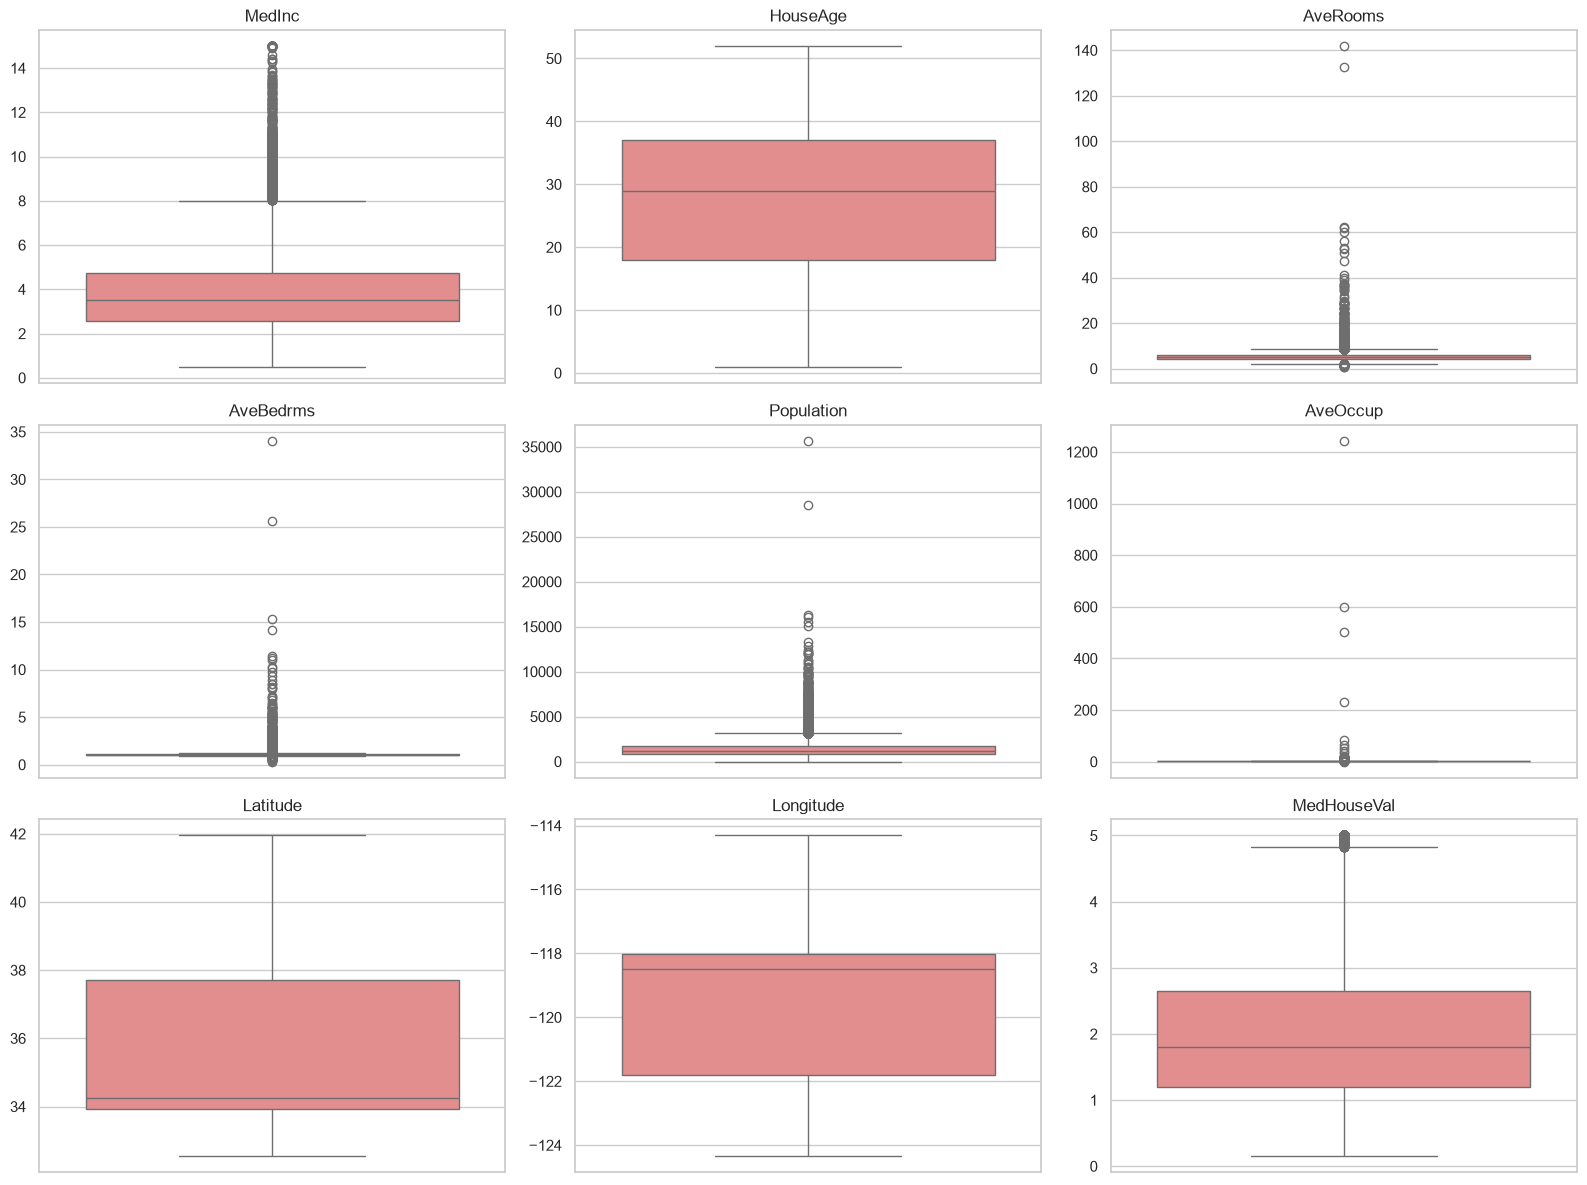

In [9]:
# Дополнительно посмотрим на выбросы глазами — через «ящики с усами».
# На таком графике прямоугольник — это центральная половина данных,
# а точки за усами — как раз выбросы.

# Создаём фигуру с сеткой графиков: 3 строки и 3 столбца.
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

# axes — это таблица осей; .ravel() превращает её в обычный плоский список.
axes = axes.ravel()

# Проходим циклом по столбцам и одновременно получаем их номер i.
for i, col in enumerate(df.columns):
    # Рисуем «ящик с усами» для текущего столбца на i-м месте.
    sns.boxplot(y=df[col], ax=axes[i], color="lightcoral")

    # Подписываем график именем столбца.
    axes[i].set_title(col)

    # Убираем подпись оси Y, чтобы не загромождать картинку.
    axes[i].set_ylabel("")

# Автоматически подгоняем отступы, чтобы подписи не налезали друг на друга.
plt.tight_layout()

# Показываем графики.
plt.show()

**Что мы увидели:**

* **AveRooms, AveBedrms, AveOccup, Population** — содержат заметную долю
  выбросов. Это реальные районы с очень большим числом комнат на человека
  (например, одиночные фермы) либо с аномально высокой плотностью.
  Данные не битые, но модели они мешают.
* **Признаки с ограниченным диапазоном** (MedInc, HouseAge, широта, долгота)
  ведут себя спокойно, выбросов почти нет.
* Выбросы мы **не удаляем и не заменяем** — это сделало бы анализ
  нечестным. Но мы их зафиксировали и учтём при выводах.

### 3.5 Важная особенность целевой переменной

У цены дома в этом датасете есть **потолок**: все значения дороже
500 000 долларов были искусственно обрезаны до 5.00001.
Это называется цензурированием данных, и оно напрямую ограничивает
потолок качества любой модели.

In [10]:
# Находим максимальное значение цены в датасете.
max_price = df["MedHouseVal"].max()
print("Максимальная цена в датасете:", max_price)

# Считаем, сколько домов упёрлись в этот потолок.
n_capped = (df["MedHouseVal"] >= 5.0).sum()
print("Домов с ценой на потолке (>= 5.0):", n_capped)

# Считаем долю таких домов среди всех.
print("Доля домов на потолке, %:", round(n_capped / len(df) * 100, 2))

# Смотрим, сколько стоит самый дешёвый дом.
print("Минимальная цена в датасете:", df["MedHouseVal"].min())

Максимальная цена в датасете: 5.00001
Домов с ценой на потолке (>= 5.0): 992
Доля домов на потолке, %: 4.81
Минимальная цена в датасете: 0.14999


**Вывод:** примерно каждый двадцатый дом имеет цену ровно на потолке.
Для этих объектов правильного ответа в данных просто нет,
поэтому идеально предсказать их невозможно — это объективный предел
для нашей модели.

### 3.6 Распределения значений

Гистограмма показывает, как часто встречается каждое значение признака.
Так видно форму распределения: симметричное оно или скошено в одну сторону.

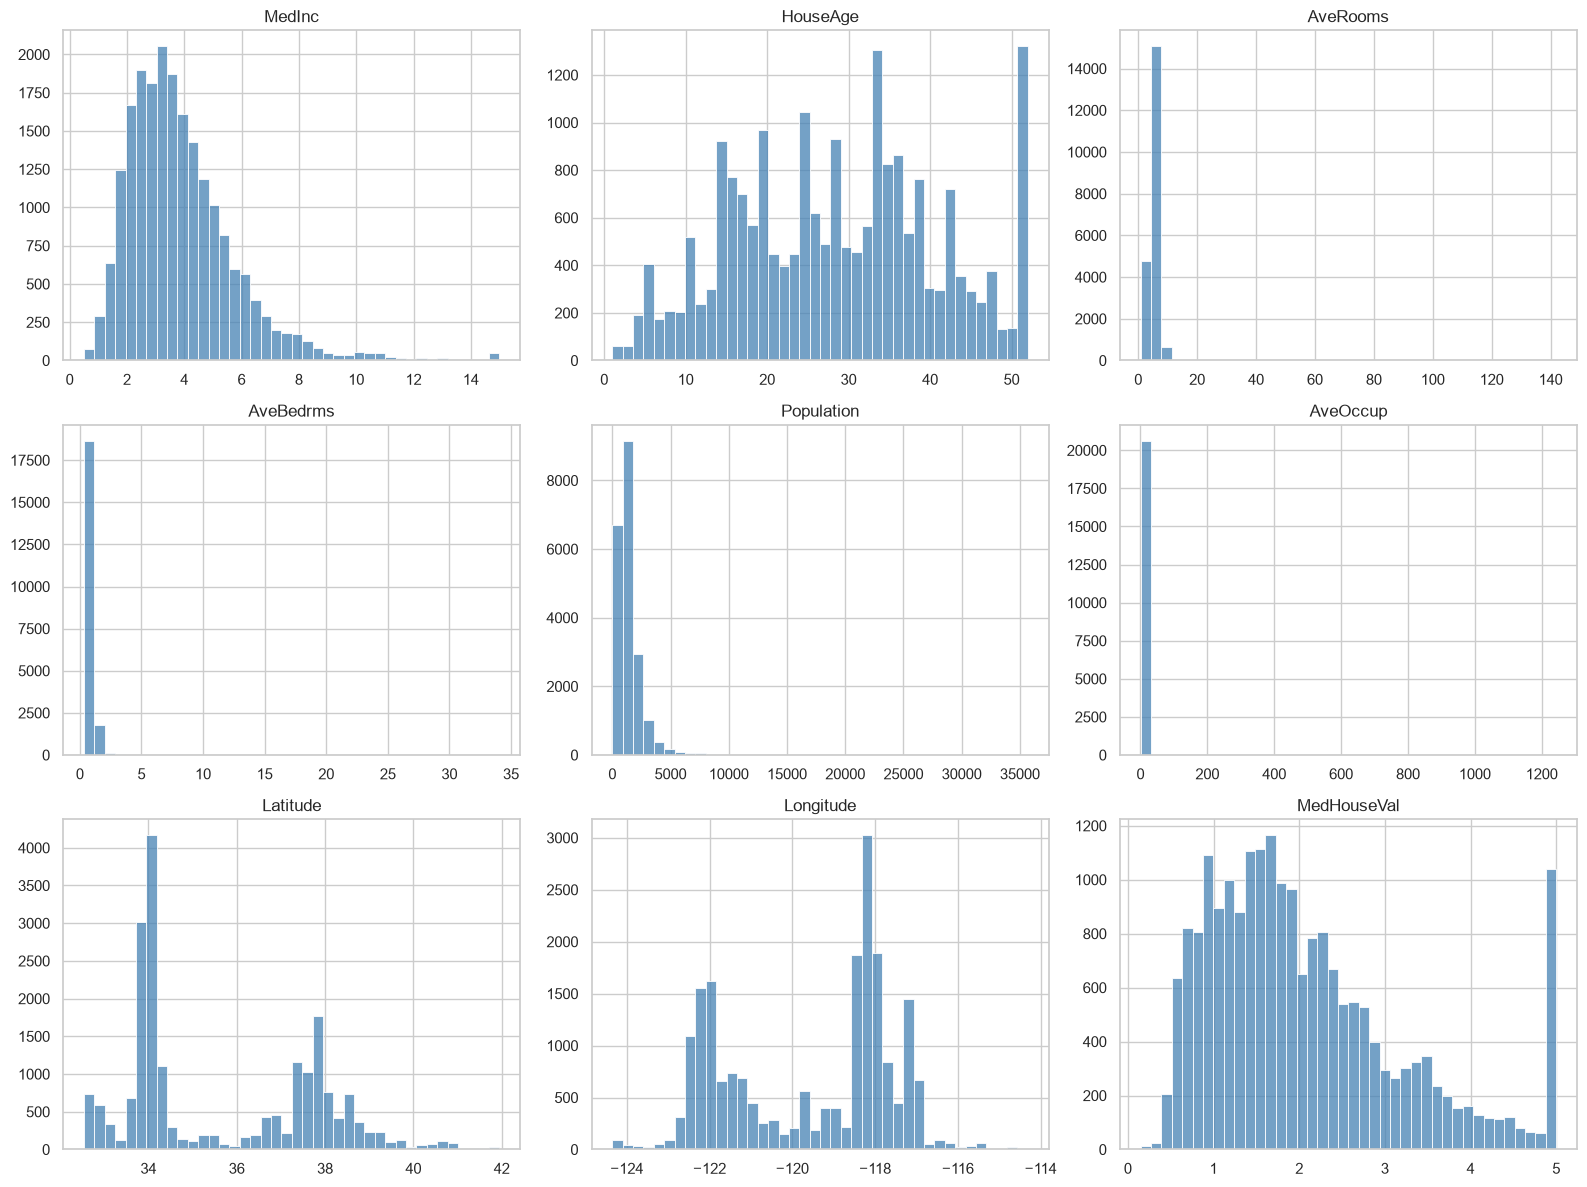

In [11]:
# Создаём фигуру с сеткой 3 на 3 — по одному графику на каждый столбец.
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

# Превращаем таблицу осей в плоский список для удобного перебора.
axes = axes.ravel()

# Проходим по каждому столбцу и его номеру.
for i, col in enumerate(df.columns):
    # Рисуем гистограмму: bins=40 — на сколько столбиков разбить диапазон.
    # color — цвет столбиков, edgecolor — цвет их границ.
    sns.histplot(df[col], bins=40, ax=axes[i], color="steelblue", edgecolor="white")

    # Подписываем график именем столбца.
    axes[i].set_title(col)

    # Убираем лишние подписи осей — названия и так понятны.
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Выравниваем отступы между графиками.
plt.tight_layout()

# Показываем результат.
plt.show()

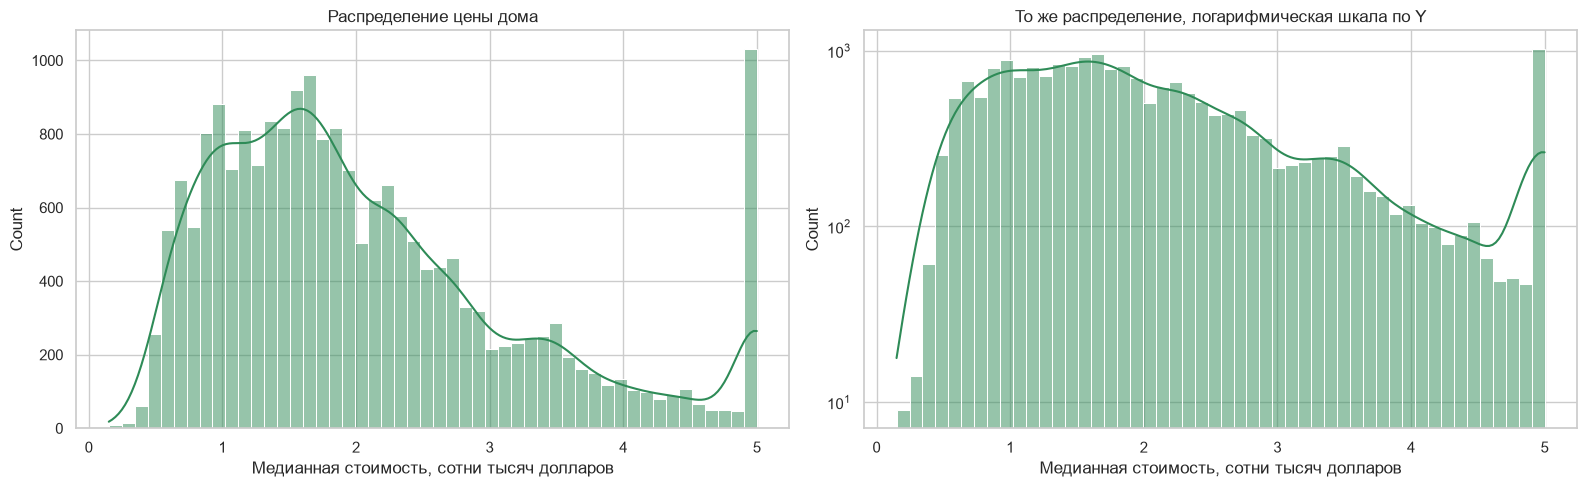

In [12]:
# Отдельно рассмотрим форму распределения цены — это наша цель.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Слева — гистограмма распределения цены.
# kde=True добавляет сверху плавную линию плотности распределения.
sns.histplot(df["MedHouseVal"], bins=50, kde=True, ax=axes[0], color="seagreen")
axes[0].set_title("Распределение цены дома")
axes[0].set_xlabel("Медианная стоимость, сотни тысяч долларов")

# Справа — тот же график, но в логарифмическом масштабе по оси Y.
# Это нужно, чтобы разглядеть редкие значения на длинном хвосте.
sns.histplot(df["MedHouseVal"], bins=50, kde=True, ax=axes[1], color="seagreen")
axes[1].set_yscale("log")
axes[1].set_title("То же распределение, логарифмическая шкала по Y")
axes[1].set_xlabel("Медианная стоимость, сотни тысяч долларов")

plt.tight_layout()
plt.show()

**Что мы увидели:**

* Цена распределена **несимметрично**: основная масса домов дешевле
  300 000 долларов, но есть длинный хвост дорогих.
* На потолке 5.0 виден отдельный «пик» — это те самые обрезанные дома.
* Признаки AveRooms, AveBedrms, Population, AveOccup имеют ярко выраженное
  правостороннее скошение: большинство значений малы, но встречаются
  очень большие.

### 3.7 Матрица корреляции

**Корреляция** — это число от −1 до +1, показывающее, связаны ли два признака:

* **+1** — признаки растут вместе (больше доход — дороже дом);
* **0** — связи нет;
* **−1** — один растёт, другой падает.

Матрица корреляции — это таблица со всеми парами признаков сразу.

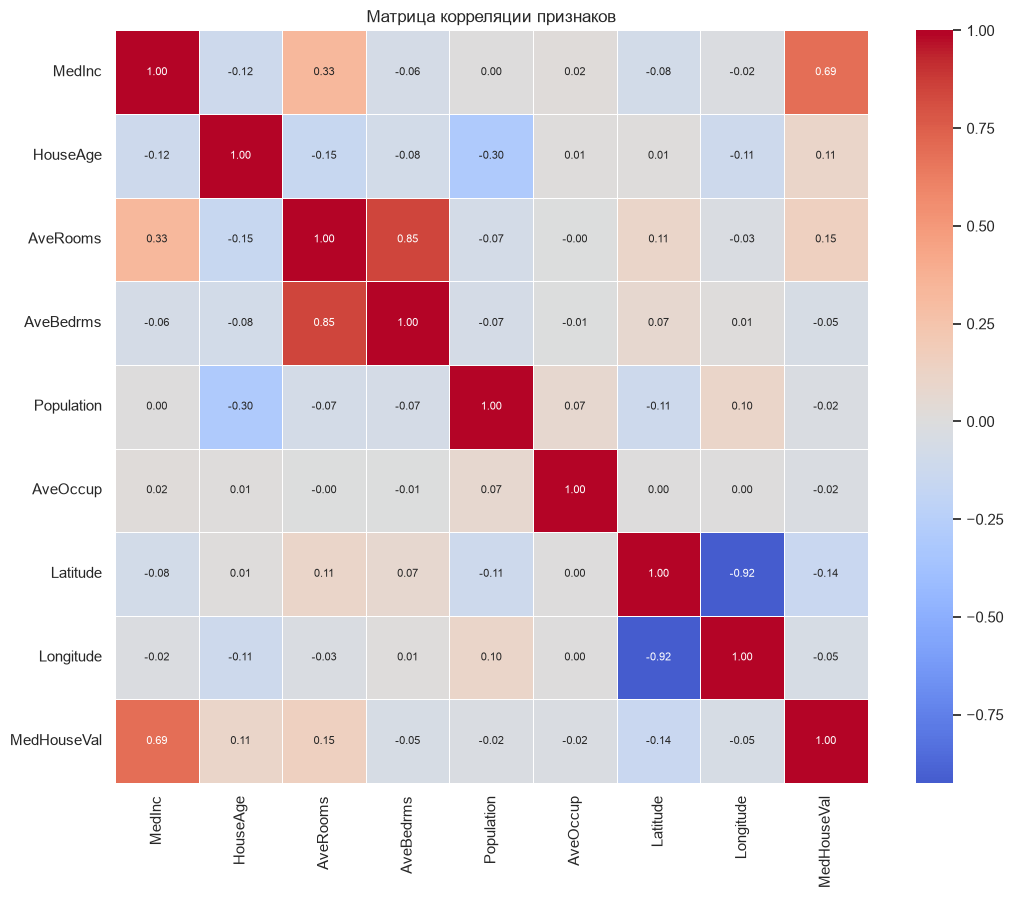

In [13]:
# Считаем корреляцию между всеми парами столбцов.
# Параметр numeric_only=True говорит считать только по числовым столбцам.
corr_matrix = df.corr(numeric_only=True)

# Создаём фигуру размером 11 на 9 — матрица большая, нужно место.
fig, ax = plt.subplots(figsize=(11, 9))

# Рисуем тепловую карту корреляции.
# annot=True — подписать каждую ячейку числом.
# fmt=".2f" — выводить числа с двумя знаками после запятой.
# cmap="coolwarm" — цветовая схема: синий для минуса, красный для плюса.
# center=0 — белый цвет соответствует нулевой корреляции.
# square=True — сделать ячейки квадратными.
# linewidths=0.5 — тонкая рамка между ячейками.
# annot_kws — размер шрифта подписей, чтобы числа влезли.
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8},
    ax=ax,
)

# Подписываем заголовок картинки.
ax.set_title("Матрица корреляции признаков")

# Выравниваем отступы и показываем график.
plt.tight_layout()
plt.show()

In [14]:
# Отдельно посмотрим, что сильнее всего связано с ценой дома.
# Берём из матрицы столбец с ценой, убираем саму цену
# и сортируем значения по убыванию абсолютной силы связи.
corr_with_target = (
    corr_matrix["MedHouseVal"]
    .drop("MedHouseVal")
    .sort_values(key=abs, ascending=False)
)

# Печатаем заголовок и саму таблицу.
print("Связь признаков с ценой дома (по убыванию силы):")
print(corr_with_target.round(3))

Связь признаков с ценой дома (по убыванию силы):
MedInc        0.688
AveRooms      0.152
Latitude     -0.144
HouseAge      0.106
AveBedrms    -0.047
Longitude    -0.046
Population   -0.025
AveOccup     -0.024
Name: MedHouseVal, dtype: float64


**Выводы по корреляции:**

* **MedInc (доход)** — самый сильный фактор: корреляция около +0.69.
  Логично: чем богаче район, тем дороже в нём жильё.
* **Latitude и Longitude** имеют заметную, но отрицательную связь.
  Это чисто географический эффект: координаты сами по себе не влияют
  на цену, но указывают на местоположение.
* **AveRooms (+0.15)** и **AveBedrms (−0.05)** связаны с ценой очень слабо.
  А вот между собой они связаны сильно и положительно: +0.85.
  Это признак мультиколлинеарности — признаки несут почти одну и ту же информацию.
* Мультиколлинеарность не ломает линейную регрессию,
  но делает отдельные коэффициенты труднообъяснимыми.

## 4. Построение модели линейной регрессии

Линейная регрессия ищет формулу вида:

    цена = a1 * MedInc + a2 * HouseAge + ... + a8 * Longitude + b

где **a1 ... a8** — коэффициенты (вклад каждого признака),
а **b** — свободный член (базовый уровень цены).

Обучение модели — это подбор таких коэффициентов,
при которых ошибка на обучающих данных минимальна.

### 4.1 Разделение данных на обучающую и тестовую выборки

Проверять модель на тех же данных, на которых она училась, нельзя:
она может просто запомнить ответы. Поэтому делим данные:

* **80 %** — обучающая выборка, на ней модель учится;
* **20 %** — тестовая выборка, на ней мы проверяем результат.

Тестовые данные модель не видела ни разу — это честная проверка.

In [15]:
# Фиксируем «зерно случайности». Одно и то же число каждый раз
# даёт одинаковое разделение данных, поэтому результат воспроизводим.
RANDOM_STATE = 42

# Делим данные на четыре части:
# X_train, y_train — признаки и ответы для обучения;
# X_test, y_test   — признаки и ответы для проверки.
# test_size=0.2 означает, что 20 % данных уходят в тест.
# random_state делает разделение воспроизводимым.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Печатаем размеры получившихся выборок.
print("Обучающие признаки X_train:", X_train.shape)
print("Обучающие ответы   y_train:", y_train.shape)
print("Тестовые признаки  X_test :", X_test.shape)
print("Тестовые ответы    y_test :", y_test.shape)

Обучающие признаки X_train: (16512, 8)
Обучающие ответы   y_train: (16512,)
Тестовые признаки  X_test : (4128, 8)
Тестовые ответы    y_test : (4128,)


### 4.2 Обучение модели

In [16]:
# Создаём экземпляр модели линейной регрессии.
# Пока это пустая, необученная модель.
model = LinearRegression()

# .fit() запускает обучение: модель смотрит на обучающие данные
# и подбирает коэффициенты. После этой строки модель готова к работе.
model.fit(X_train, y_train)

# Печатаем сообщение об успехе.
print("Модель обучена.")

# Печатаем свободный член — базовый уровень предсказания.
print()
print("Свободный член (intercept):", round(model.intercept_, 4))

# Печатаем коэффициенты — вклад каждого признака.
# model.coef_ — это массив, по одному числу на каждый признак.
print()
print("Коэффициенты модели:")
for name, coef in zip(X.columns, model.coef_):
    print(f"  {name:12s} : {coef:+.6f}")

Модель обучена.

Свободный член (intercept): -37.0233

Коэффициенты модели:
  MedInc       : +0.448675
  HouseAge     : +0.009724
  AveRooms     : -0.123323
  AveBedrms    : +0.783145
  Population   : -0.000002
  AveOccup     : -0.003526
  Latitude     : -0.419792
  Longitude    : -0.433708


**Как читать коэффициенты:**

* **MedInc: +0.45** — при росте дохода на единицу цена растёт
  примерно на 0.45 (то есть на 45 000 долларов). Самый понятный и ожидаемый эффект.
* **AveBedrms: +0.78** — знак плюс здесь **обманчив**. Дело в том, что AveBedrms
  связан с AveRooms положительно, с корреляцией +0.85, и связано это с тем,
  как устроены данные. Модель «перекинула» вес между этими двумя признаками.
  Это и есть мультиколлинеарность — коэффициенты по отдельности
  перестают иметь прямой смысл.
* **AveRooms: −0.12 и AveOccup: −0.0035** — небольшие отрицательные вклады,
  работающие в паре с предыдущими признаками.
* **Широта и долгота** получили веса −0.42 и −0.43:
  модель выучила, что часть координат соответствует более дорогим районам.

Вывод: коэффициенты линейной регрессии нельзя трактовать по одному,
если признаки связаны между собой.

### 4.3 Прогноз и оценка качества

Используем две метрики:

**MSE (среднеквадратическая ошибка)** — среднее значение квадрата разности
между прогнозом и правдой. Чем меньше, тем лучше. Измеряется
в квадратных единицах цены, поэтому по ней судят скорее об относительной точности.

**R² (коэффициент детерминации)** — доля закономерностей в данных,
которую объяснила модель. Измеряется от 0 до 1:

* **R² = 1** — идеальное предсказание;
* **R² = 0** — модель не лучше, чем просто назвать всем среднюю цену;
* **R² < 0** — модель хуже такого «среднего» прогноза.

In [17]:
# Просим модель предсказать цену для тестовых данных.
# Модель эти дома не видела при обучении.
y_pred = model.predict(X_test)

# Считаем MSE: среднюю квадратичную ошибку между правдой и прогнозом.
mse = mean_squared_error(y_test, y_pred)

# Считаем RMSE — квадратный корень из MSE.
# RMSE удобнее тем, что измеряется в тех же единицах, что и цена.
rmse = np.sqrt(mse)

# Считаем R² — какую долю разброса цен объяснила модель.
r2 = r2_score(y_test, y_pred)

# Печатаем все метрики.
print("--- Качество модели на тестовой выборке ---")
print(f"MSE  (среднеквадратическая ошибка) : {mse:.4f}")
print(f"RMSE (корень из MSE)               : {rmse:.4f}")
print(f"R2   (коэффициент детерминации)    : {r2:.4f}")

# Переводим RMSE в понятные деньги.
# Цена измеряется в сотнях тысяч долларов, значит умножаем на 100 000.
print()
print(f"Средняя ошибка модели: около {rmse * 100000:,.0f} долларов")

--- Качество модели на тестовой выборке ---
MSE  (среднеквадратическая ошибка) : 0.5559
RMSE (корень из MSE)               : 0.7456
R2   (коэффициент детерминации)    : 0.5758

Средняя ошибка модели: около 74,558 долларов


### 4.4 Визуализация качества прогноза

Самый наглядный способ проверить регрессию — построить график
«прогноз против правды». Идеальная модель дала бы ровную диагональ:
прогноз в точности равен факту.

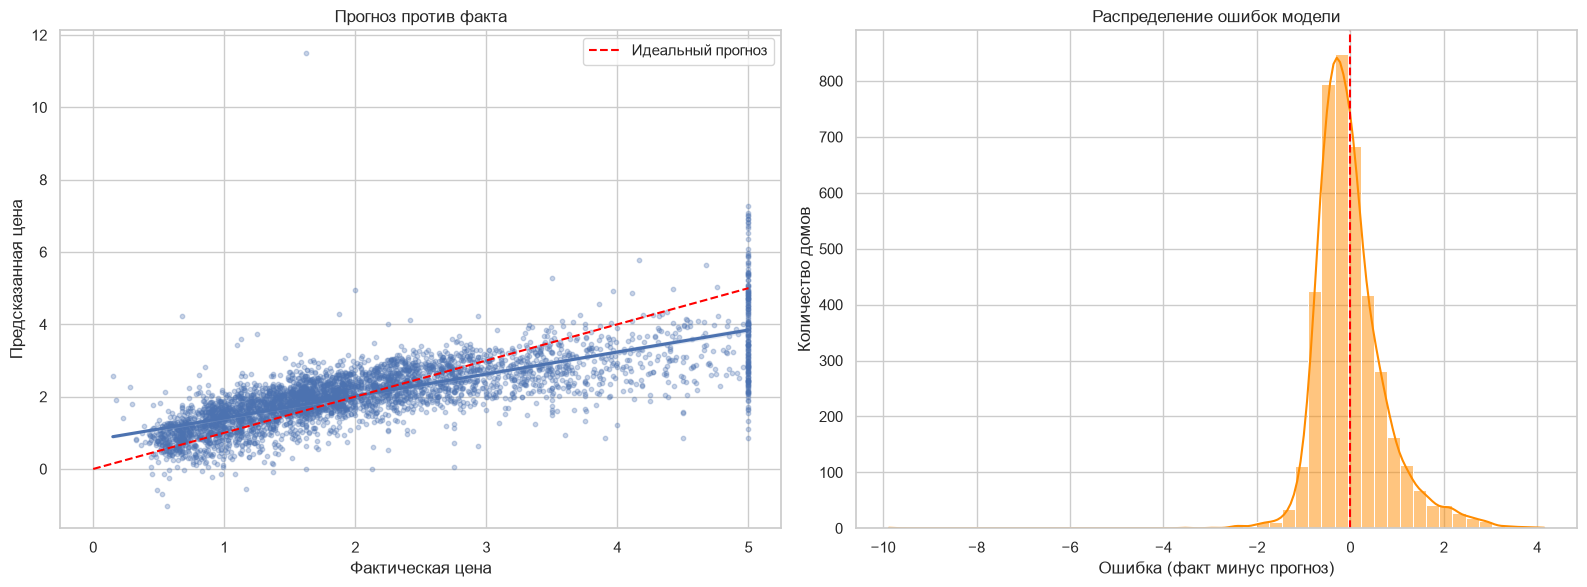

In [18]:
# Создаём фигуру с двумя графиками рядом.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- График 1: прогноз против факта ---

# sns.regplot рисует точки и подгоняет прямую линию через них.
# x — фактические значения, y — предсказанные.
# alpha=0.3 делает точки полупрозрачными, иначе плотное облако сольётся в пятно.
sns.regplot(x=y_test, y=y_pred, ax=axes[0], scatter_kws={"alpha": 0.3, "s": 10})

# Добавляем идеальную диагональ — линию «прогноз равен факту».
# Если бы модель была идеальной, все точки лежали бы на этой линии.
axes[0].plot([0, 5], [0, 5], color="red", linestyle="--", label="Идеальный прогноз")

# Подписываем оси и заголовок.
axes[0].set_xlabel("Фактическая цена")
axes[0].set_ylabel("Предсказанная цена")
axes[0].set_title("Прогноз против факта")

# Включаем легенду.
axes[0].legend()

# --- График 2: остатки ---

# Остаток — это разница между фактом и прогнозом: насколько модель ошиблась.
residuals = y_test - y_pred

# Рисуем распределение остатков.
sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color="darkorange")

# Рисуем вертикальную линию на нуле — это «идеальная» ошибка.
axes[1].axvline(0, color="red", linestyle="--")

# Подписываем оси и заголовок.
axes[1].set_xlabel("Ошибка (факт минус прогноз)")
axes[1].set_ylabel("Количество домов")
axes[1].set_title("Распределение ошибок модели")

plt.tight_layout()
plt.show()

**Как читать эти графики:**

* На левом графике облако точек идёт вдоль диагонали, но заметно **шире**
  в области дорогих домов. Значит, дешёвые дома модель предсказывает
  точнее, чем дорогие.
* Видна **горизонтальная полоса точек** на уровне цены 5.0 —
  это дома, упёршиеся в потолок, о котором мы говорили в пункте 3.5.
  Модель не может их различить, потому что в данных они одинаковы.
* На правом графике остатки сосредоточены около нуля и примерно симметричны.
  Это хороший знак: модель не имеет постоянного смещения в одну сторону.
  Но у распределения есть длинный правый хвост — модель иногда сильно
  недооценивает дорогие дома.

## 5. Эксперименты в MLflow

**MLflow** — инструмент для ведения журнала экспериментов.
Он записывает параметры модели, метрики и саму модель,
чтобы потом можно было сравнить разные запуски между собой
и не потерять результаты.

Сравним базовую модель с улучшенным вариантом, у которого мы уберём
единичные экстремальные значения в признаке AveRooms.

In [19]:
# Указываем MLflow, где хранить журнал экспериментов.
# Мы используем базу данных SQLite — это надёжнее и быстрее,
# чем хранение в виде файлов.
mlflow.set_tracking_uri("sqlite:///mlflow.db")

# Задаём имя эксперимента. Все запуски ниже попадут в этот эксперимент.
# Если такого эксперимента ещё нет, MLflow создаст его автоматически.
mlflow.set_experiment("California_Housing_LinearRegression")

print("MLflow настроен.")
print("Хранилище экспериментов: mlflow.db")

MLflow настроен.
Хранилище экспериментов: mlflow.db


In [20]:
# Вспомним: при просмотре датасета мы видели длинный правый хвост
# в признаках AveRooms, AveBedrms, AveOccup и Population.
# Уберём крайние 1 % значений по каждому из этих признаков.
# Это стандартный приём, он часто улучшает линейную регрессию.

# Список признаков, которые будем чистить.
SKEWED = ["AveRooms", "AveBedrms", "AveOccup", "Population"]

# Описываем функцию для очистки признаков от экстремальных хвостов.
def clip_extremes(data, columns, low=0.01, high=0.99):
    """Обрезает крайние значения в указанных столбцах до заданных процентилей."""

    # Копируем таблицу, чтобы не менять исходную.
    result = data.copy()

    # Проходим по каждому столбцу из списка.
    for col in columns:
        # .quantile() находит нужные границы, .clip() обрезает значения по ним.
        result[col] = result[col].clip(
            lower=result[col].quantile(low),   # нижняя граница — 1-й процентиль
            upper=result[col].quantile(high),  # верхняя граница — 99-й процентиль
        )

    # Возвращаем очищенную таблицу.
    return result


# Применяем очистку к признакам.
X_clean = clip_extremes(X, SKEWED)

# Печатаем, как изменились максимальные значения после очистки.
print("Максимум до очистки:")
print(X[SKEWED].max().round(2))
print()
print("Максимум после очистки:")
print(X_clean[SKEWED].max().round(2))

Максимум до очистки:
AveRooms        141.91
AveBedrms        34.07
AveOccup       1243.33
Population    35682.00
dtype: float64

Максимум после очистки:
AveRooms        10.36
AveBedrms        2.13
AveOccup         5.39
Population    5805.83
dtype: float64


In [21]:
# Повторяем разделение данных, но уже по очищенным признакам.
# random_state используем тот же, чтобы сравнение было честным.
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Данные для второго эксперимента подготовлены.")
print("Xc_train:", Xc_train.shape, "| Xc_test:", Xc_test.shape)

Данные для второго эксперимента подготовлены.
Xc_train: (16512, 8) | Xc_test: (4128, 8)


In [22]:
# Оформляем первый эксперимент в MLflow.
# Оператор with открывает запуск и автоматически закрывает его в конце.
with mlflow.start_run(run_name="linear_regression_baseline"):

    # Записываем параметры эксперимента:
    # по ним потом можно отличить один запуск от другого.
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("features", "all 8 raw features")
    mlflow.log_param("test_size", 0.2)
    mlflow.log_param("random_state", RANDOM_STATE)

    # Обучаем модель на исходных (неочищенных) данных.
    baseline_model = LinearRegression()
    baseline_model.fit(X_train, y_train)

    # Делаем прогноз на исходных тестовых данных.
    baseline_pred = baseline_model.predict(X_test)

    # Считаем метрики качества.
    baseline_mse = mean_squared_error(y_test, baseline_pred)
    baseline_r2 = r2_score(y_test, baseline_pred)

    # Записываем метрики в MLflow. Их можно будет сравнить между запусками.
    mlflow.log_metric("mse", baseline_mse)
    mlflow.log_metric("rmse", float(np.sqrt(baseline_mse)))
    mlflow.log_metric("r2", baseline_r2)

    # Сохраняем саму обученную модель в MLflow.
    mlflow.sklearn.log_model(baseline_model, name="model")

    # Печатаем результат запуска.
    print("Эксперимент 1: базовая модель на исходных данных")
    print(f"  MSE : {baseline_mse:.4f}")
    print(f"  R2  : {baseline_r2:.4f}")

Эксперимент 1: базовая модель на исходных данных
  MSE : 0.5559
  R2  : 0.5758


In [23]:
# Оформляем второй эксперимент — с очищенными от выбросов признаками.
with mlflow.start_run(run_name="linear_regression_clipped_outliers"):

    # Записываем параметры. Теперь видно, чем этот запуск отличается.
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("features", "clipped 1-99 percentile: " + ", ".join(SKEWED))
    mlflow.log_param("test_size", 0.2)
    mlflow.log_param("random_state", RANDOM_STATE)

    # Обучаем точно такую же модель, но на очищенных данных.
    clean_model = LinearRegression()
    clean_model.fit(Xc_train, yc_train)

    # Делаем прогноз на очищенных тестовых данных.
    clean_pred = clean_model.predict(Xc_test)

    # Считаем метрики.
    clean_mse = mean_squared_error(yc_test, clean_pred)
    clean_r2 = r2_score(yc_test, clean_pred)

    # Записываем метрики в MLflow.
    mlflow.log_metric("mse", clean_mse)
    mlflow.log_metric("rmse", float(np.sqrt(clean_mse)))
    mlflow.log_metric("r2", clean_r2)

    # Сохраняем модель.
    mlflow.sklearn.log_model(clean_model, name="model")

    # Печатаем результат.
    print("Эксперимент 2: модель на очищенных данных")
    print(f"  MSE : {clean_mse:.4f}")
    print(f"  R2  : {clean_r2:.4f}")

Эксперимент 2: модель на очищенных данных
  MSE : 0.4620
  R2  : 0.6475


In [24]:
# Сравниваем два эксперимента в одной таблице.
print("=" * 62)
print("СРАВНЕНИЕ ЭКСПЕРИМЕНТОВ")
print("=" * 62)
print(f"{'Модель':<38}{'MSE':>10}{'R2':>12}")
print("-" * 62)
print(f"{'1. Базовая (исходные данные)':<38}{baseline_mse:>10.4f}{baseline_r2:>12.4f}")
print(f"{'2. С очисткой выбросов':<38}{clean_mse:>10.4f}{clean_r2:>12.4f}")
print("-" * 62)

# Считаем, насколько улучшился R2 во втором эксперименте.
delta_r2 = clean_r2 - baseline_r2
print(f"Изменение R2: {delta_r2:+.4f}")

# Печатаем вывод в зависимости от знака изменения.
if delta_r2 > 0:
    print("Вывод: очистка выбросов улучшила качество модели.")
else:
    print("Вывод: очистка выбросов не дала улучшения на этом датасете.")

СРАВНЕНИЕ ЭКСПЕРИМЕНТОВ
Модель                                       MSE          R2
--------------------------------------------------------------
1. Базовая (исходные данные)              0.5559      0.5758
2. С очисткой выбросов                    0.4620      0.6475
--------------------------------------------------------------
Изменение R2: +0.0717
Вывод: очистка выбросов улучшила качество модели.


### Как посмотреть результаты MLflow

MLflow сохраняет всё в файл **mlflow.db** в папке с ноутбуком.
Чтобы открыть веб-интерфейс и увидеть графики сравнения запусков,
выполните в терминале команду:

    mlflow ui --backend-store-uri sqlite:///mlflow.db

Затем откройте в браузере адрес http://127.0.0.1:5000 —
там будут видны оба запуска, их параметры, метрики и сохранённые модели.

## 6. Выводы

**Что сделано:**

1. Загружен и описан датасет California Housing: 20 640 районов, 8 признаков.
2. Проведён разведочный анализ: пропусков и дубликатов не найдено,
   зафиксированы выбросы в четырёх признаках.
3. Обнаружена важная особенность: цена дома обрезана сверху значением 5.00001
   (около 5 % домов). Это объективный предел точности любой модели.
4. Построены распределения и матрица корреляции.
   Сильнейший фактор цены — доход жителей (корреляция +0.69).
5. Обучена линейная регрессия и оценена на тестовой выборке.
6. Проведены два эксперимента в MLflow и выполнено их сравнение.

**Ключевой результат:** R² около 0.58 у базовой модели и около 0.65 после очистки
выбросов. Это означает, что линейная регрессия объясняет примерно 58–65 %
разброса цен. Для такой простой модели это
нормальный результат, но остаётся 40 % необъяснённых различий.

**Почему качество не выше:**

* **Линейная зависимость.** Регрессия умеет рисовать только прямую.
  Реальная зависимость цены от расположения сложнее: районы у океана
  дороги нелинейно.
* **Потолок цены.** Для ~5 % домов правильного ответа в данных нет.
* **Мультиколлинеарность.** AveRooms и AveBedrms связаны между собой,
  из-за чего их коэффициенты теряют прямой смысл.
* **Пропущенные факторы.** В данных нет этажности, состояния дома,
  близости к центру и школам — а они сильно влияют на цену.
* **Необработанные координаты.** Широта и долгота подставлены в модель
  как обычные числа, хотя расстояние на карте считается иначе.

**Что можно улучшить дальше:**

* добавить новые признаки из координат (расстояние до океана, до крупных городов);
* применить полиномиальные признаки — это позволит модели учитывать нелинейность;
* попробовать регуляризацию Ridge или Lasso, которая борется с мультиколлинеарностью;
* сравнить с деревом решений и случайным лесом, которые не требуют линейной зависимости.